### Clase 6

In [4]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
target_labels = cancer.target[[10, 20, 30]]
print("labels:", target_labels)
print("clase:", cancer.target_names[target_labels])

labels: [0 1 0]
clase: ['malignant' 'benign' 'malignant']


In [5]:
correlation = df.corr()
correlation_target = correlation['target']
correlation_absolute = correlation_target.abs()
correlation_sorted = correlation_absolute.sort_values(ascending=False)
print(correlation_sorted)

target                     1.000000
worst concave points       0.793566
worst perimeter            0.782914
mean concave points        0.776614
worst radius               0.776454
mean perimeter             0.742636
worst area                 0.733825
mean radius                0.730029
mean area                  0.708984
mean concavity             0.696360
worst concavity            0.659610
mean compactness           0.596534
worst compactness          0.590998
radius error               0.567134
perimeter error            0.556141
area error                 0.548236
worst texture              0.456903
worst smoothness           0.421465
worst symmetry             0.416294
mean texture               0.415185
concave points error       0.408042
mean smoothness            0.358560
mean symmetry              0.330499
worst fractal dimension    0.323872
compactness error          0.292999
concavity error            0.253730
fractal dimension error    0.077972
smoothness error           0

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
umbral_wc = 0.1251
df['prediction_wcp'] = (df['worst concave points'] <= umbral_wc).astype(int)
cm_wc = confusion_matrix(df['target'], df['prediction_wcp'])
print(round(accuracy_score(df['target'], df['prediction_wcp']), 4))
print(round(precision_score(df['target'], df['prediction_wcp']), 4))
print(round(recall_score(df['target'], df['prediction_wcp']), 4))
print(round(f1_score(df['target'], df['prediction_wcp']), 4))

0.9033
0.9339
0.9104
0.922


#### 5 <br> Implementación del PCA

In [17]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X = df[cancer['feature_names']]

In [19]:
X_mean = X.mean()
X_std = X.std()
Z = (X- X_mean) / X_std

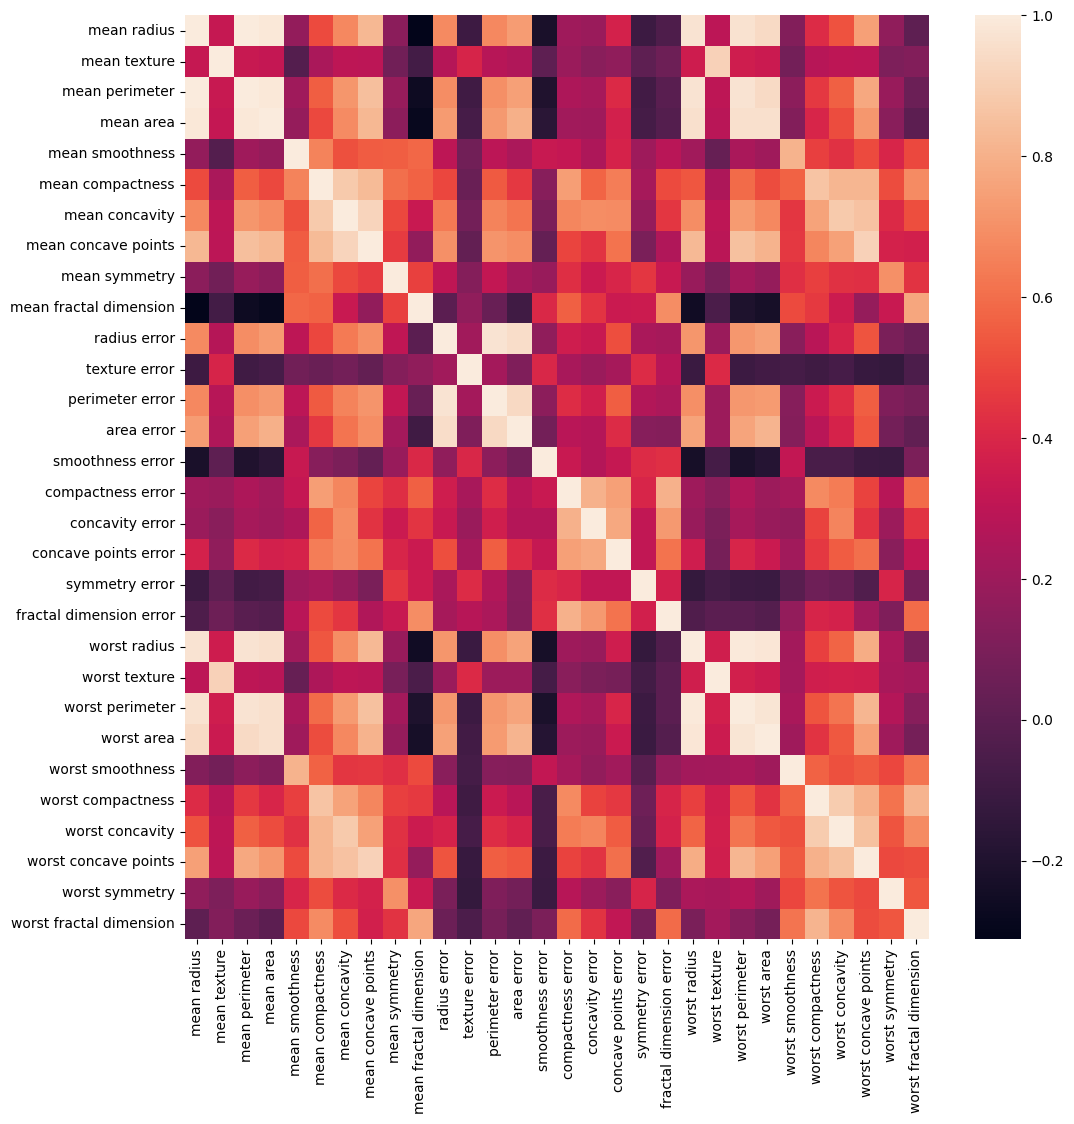

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
c = Z.cov()
plt.figure(figsize=(12, 12))
sns.heatmap(c)
plt.show()

In [36]:
import numpy as np
eigenvalues, eigenvectors = np.linalg.eig(c)
print('Valores propios:\n', eigenvalues)
print('Forma de los valores propios:', eigenvalues.shape)
print('Forma de los vectores propios:', eigenvectors.shape)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Valores propios:
 [1.32816077e+01 5.69135461e+00 2.81794898e+00 1.98064047e+00
 1.64873055e+00 1.20735661e+00 6.75220114e-01 4.76617140e-01
 4.16894812e-01 3.50693457e-01 2.93915696e-01 2.61161370e-01
 2.41357496e-01 1.57009724e-01 9.41349650e-02 7.98628010e-02
 5.93990378e-02 5.26187835e-02 4.94775918e-02 1.33044823e-04
 7.48803097e-04 1.58933787e-03 6.90046388e-03 8.17763986e-03
 1.54812714e-02 1.80550070e-02 2.43408378e-02 2.74394025e-02
 3.11594025e-02 2.99728939e-02]
Forma de los valores propios: (30,)
Forma de los vectores propios: (30, 30)


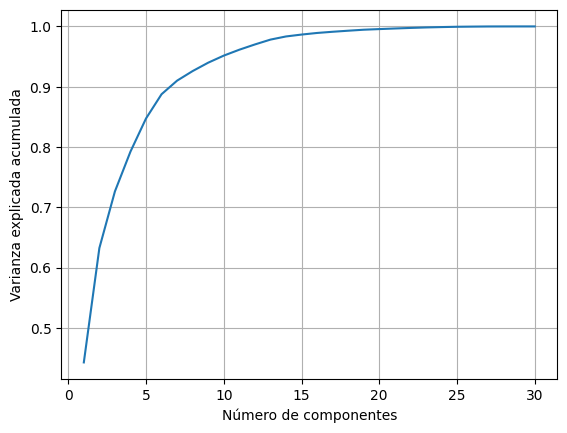

In [38]:
explained_var = np.cumsum(eigenvalues) / np.sum(eigenvalues)
plt.plot(range(1, len(explained_var) + 1), explained_var)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid()
plt.show()

In [40]:
n_components = np.argmax(explained_var >= 0.50) + 1
n_components

np.int64(2)

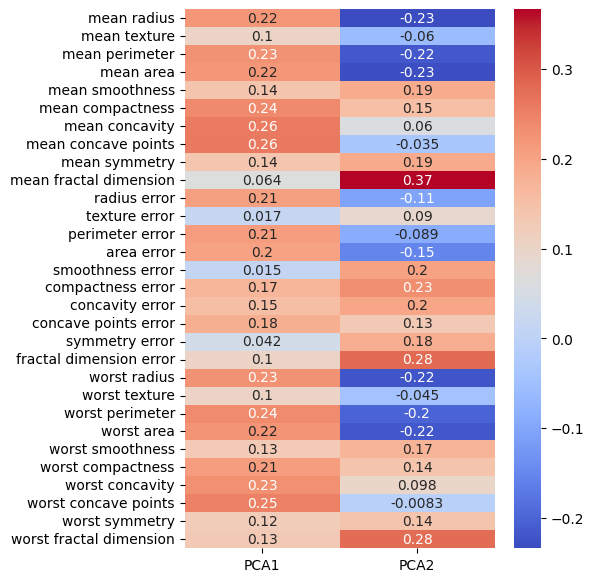

In [41]:
u = eigenvectors[:, :n_components]
pca_component = pd.DataFrame(u, 
                             index = cancer['feature_names'],
                             columns = ['PCA1', 'PCA2'])
plt.figure(figsize =(5, 7))
sns.heatmap(pca_component, annot=True, cmap='coolwarm')
plt.show()

In [42]:
Z_pca = Z @ pca_component
Z_pca.columns = ['PCA1', 'PCA2']
print(Z_pca)

          PCA1       PCA2
0     9.184755   1.946870
1     2.385703  -3.764859
2     5.728855  -1.074229
3     7.116691  10.266556
4     3.931842  -1.946359
..         ...        ...
564   6.433655  -3.573673
565   3.790048  -3.580897
566   1.255075  -1.900624
567  10.365673   1.670540
568  -5.470430  -0.670047

[569 rows x 2 columns]


In [43]:
print(Z_pca[['PCA1', 'PCA2']].corr())

              PCA1          PCA2
PCA1  1.000000e+00  2.795822e-16
PCA2  2.795822e-16  1.000000e+00


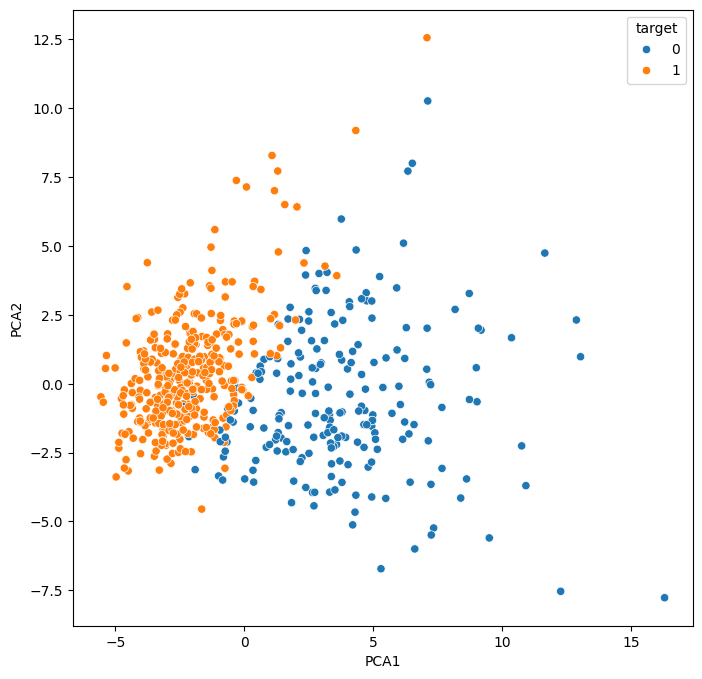

In [44]:
Z_pca['target'] = df['target']
plt.figure(figsize=(8,8))
sns.scatterplot(data=Z_pca, x="PCA1", y="PCA2", hue="target")
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
umbral1 = Z_pca[Z_pca['target'] == 0]['PCA1'].median()
umbral2 = Z_pca[Z_pca['target'] == 0]['PCA2'].median()
Z_pca['pred_pca'] = ((Z_pca['PCA1'] >= umbral1) | (Z_pca['PCA2'] >= umbral2)).astype(int)
cm_pca12 = confusion_matrix(Z_pca['target'], Z_pca['pred_pca'])
print(accuracy_score(Z_pca['target'], Z_pca['pred_pca']))
print(precision_score(Z_pca['target'], Z_pca['pred_pca']))
print(recall_score(Z_pca['target'], Z_pca['pred_pca']))
print(f1_score(Z_pca['target'], Z_pca['pred_pca']))

0.5588752196836555
0.625
0.742296918767507
0.678617157490397


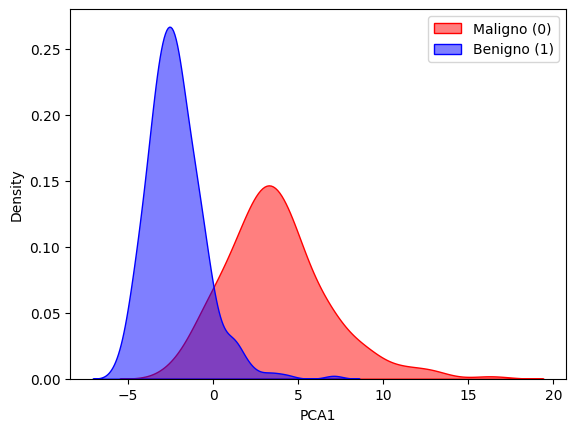

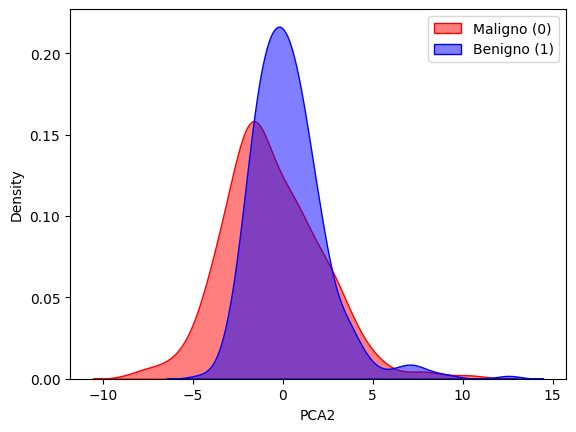

In [77]:
sns.kdeplot(Z_pca[Z_pca['target'] == 0]['PCA1'], label="Maligno (0)", fill=True, color="red", alpha=0.5)
sns.kdeplot(Z_pca[Z_pca['target'] == 1]['PCA1'], label="Benigno (1)", fill=True, color="blue", alpha=0.5)
plt.legend()
plt.show()
sns.kdeplot(Z_pca[Z_pca['target'] == 0]['PCA2'], label="Maligno (0)", fill=True, color="red", alpha=0.5)
sns.kdeplot(Z_pca[Z_pca['target'] == 1]['PCA2'], label="Benigno (1)", fill=True, color="blue", alpha=0.5)
plt.legend()

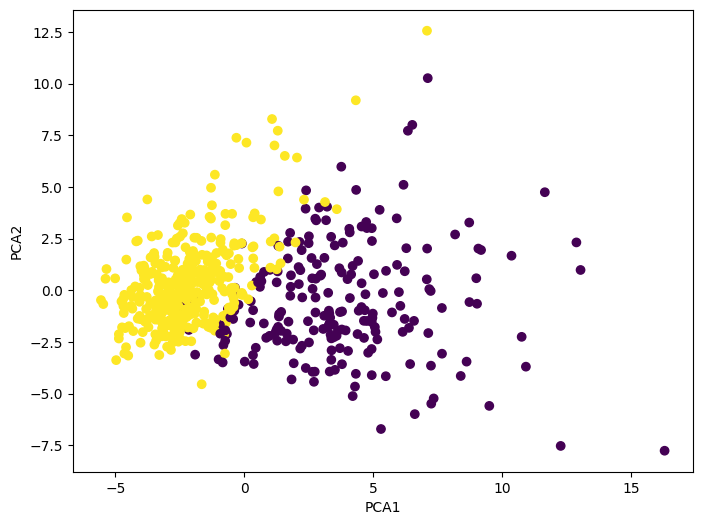

In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(Z)
x_pca = pca.transform(Z)
df_pca1 = pd.DataFrame(x_pca, 
                       columns=['PC{}'.format(i+1) for i in range(n_components)])
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cancer['target'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()